# Análisis Exploratorio de Datos (EDA)
## Demanda Eléctrica Real — ZMVM (2016–2024)

Este notebook explora los datos de demanda eléctrica real del Sistema Nacional Eléctrico (CENACE),
con énfasis en la **Gerencia Central (CEN)** que cubre la Zona Metropolitana del Valle de México.

**Fuente:** CENACE SIM Portal — Estimación de Demanda por Balance
**Periodo:** Abril 2016 – Diciembre 2024
**Granularidad:** Horaria (24 obs/día × 9 áreas)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import sys

# Agregar src al path
sys.path.insert(0, str(Path('..').resolve()))

# Estilos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 1. Carga de Datos

In [2]:
RAW_DIR = Path('..') / 'data' / 'raw'
PARQUET = RAW_DIR / 'demanda_real_combined.parquet'

df = pd.read_parquet(PARQUET)
print(f'Filas totales:  {len(df):>10,}')
print(f'Columnas:       {list(df.columns)}')
print(f'Rango temporal: {df.fecha.min().date()} → {df.fecha.max().date()}')
print(f'\nNulos por columna:')
print(df.isnull().sum())
df.head()

Filas totales:   3,151,218
Columnas:       ['sistema', 'area', 'hora', 'generacion_mwh', 'exportacion_total_mwh', 'demanda_balance_mwh', 'source_file', 'importacion_mwh', 'intercambio_mwh', 'fecha']
Rango temporal: 2016-04-01 → 2024-12-31

Nulos por columna:
sistema                        0
area                           0
hora                           0
generacion_mwh                 0
exportacion_total_mwh     362234
demanda_balance_mwh            0
source_file                    0
importacion_mwh          1280666
intercambio_mwh          1280666
fecha                          0
dtype: int64


,sistema,area,hora,generacion_mwh,exportacion_total_mwh,demanda_balance_mwh,source_file,importacion_mwh,intercambio_mwh,fecha
0,BCA,BCA,1,"1,272.17",115.00,"1,157.17",Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
1,BCS,BCS,1,191.33,0.00,191.33,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
2,SIN,CEN,1,"4,828.71",0.00,"4,828.71",Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
3,SIN,NES,1,"9,737.85",0.00,"9,737.85",Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
4,SIN,NOR,1,"2,261.77",0.00,"2,261.77",Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01


In [3]:
# Filtrar área CEN (Gerencia Central = ZMVM)
cen = df[df['area'] == 'CEN'].copy()
cen = cen.sort_values(['fecha', 'hora']).reset_index(drop=True)

# Crear columna datetime completa
cen['datetime'] = cen['fecha'] + pd.to_timedelta(cen['hora'] - 1, unit='h')
cen['anio']     = cen['fecha'].dt.year
cen['mes']      = cen['fecha'].dt.month
cen['dia_sem']  = cen['fecha'].dt.dayofweek   # 0=Lunes
cen['dia_sem_nombre'] = cen['fecha'].dt.day_name(locale='es_MX')
cen['semana']   = cen['fecha'].dt.isocalendar().week.astype(int)

print(f'Filas CEN: {len(cen):,}')
print(f'Horas faltantes (gaps > 1h): ', end='')
gaps = cen['datetime'].diff().dt.total_seconds() / 3600
print((gaps > 1.5).sum())
cen[['datetime','hora','demanda_balance_mwh']].describe()

Filas CEN: 350,135
Horas faltantes (gaps > 1h): 7


,datetime,hora,demanda_balance_mwh
count,350135,"350,135.00","350,135.00"
mean,2020-09-10 23:20:05.134019328,12.50,"5,634.00"
min,2016-04-01 00:00:00,1.00,"1,126.68"
25%,2018-06-21 11:00:00,6.50,"4,669.90"
50%,2020-10-07 08:00:00,12.00,"5,702.01"
75%,2022-11-22 03:00:00,18.00,"6,909.66"
max,2024-12-31 23:00:00,25.00,"8,712.81"
std,NaN,6.92,"1,472.39"


## 2. Vista General de la Serie Temporal

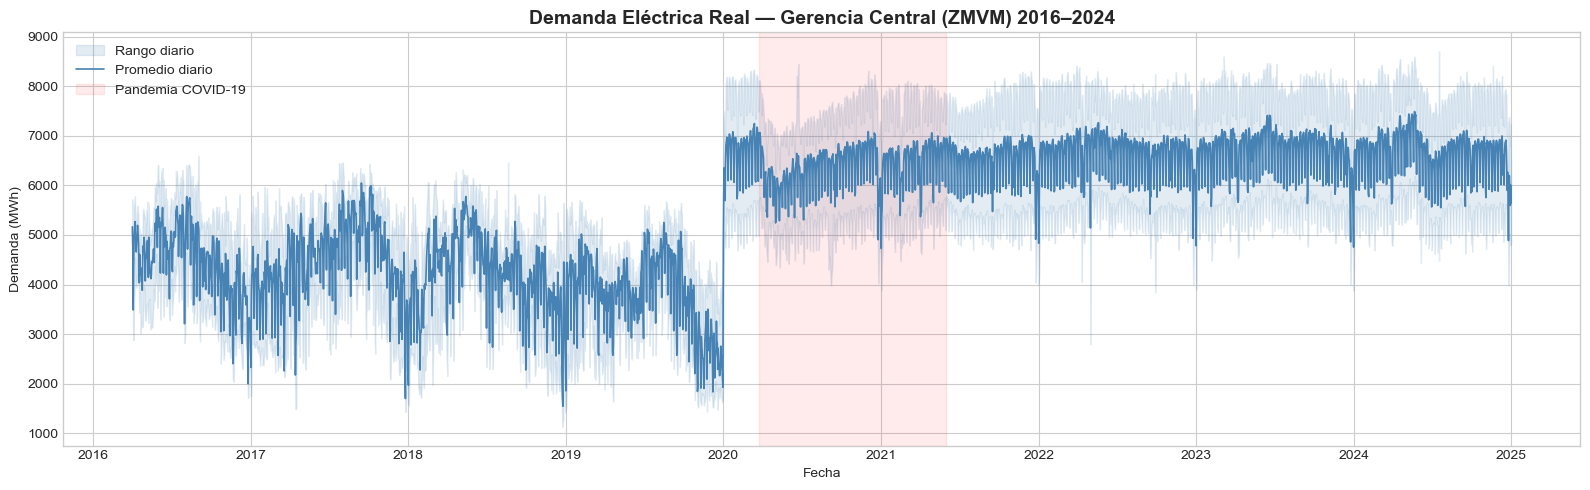

In [4]:
# Serie completa 2016-2024
daily = cen.groupby('fecha')['demanda_balance_mwh'].agg(['mean','min','max']).reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(daily['fecha'], daily['min'], daily['max'], alpha=0.15, color='steelblue', label='Rango diario')
ax.plot(daily['fecha'], daily['mean'], color='steelblue', lw=1.2, label='Promedio diario')

# Resaltar COVID-19
ax.axvspan(pd.Timestamp('2020-03-23'), pd.Timestamp('2021-06-01'),
           alpha=0.08, color='red', label='Pandemia COVID-19')

ax.set_title('Demanda Eléctrica Real — Gerencia Central (ZMVM) 2016–2024',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda (MWh)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../reports/figures/01_serie_completa_cen.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Estadísticas Descriptivas

In [5]:
print('=== Estadísticas por Año (Demanda CEN, MWh) ===')
yearly_stats = cen.groupby('anio')['demanda_balance_mwh'].agg(
    count='count',
    media='mean',
    mediana='median',
    desv_std='std',
    minimo='min',
    maximo='max',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
)
yearly_stats

=== Estadísticas por Año (Demanda CEN, MWh) ===


,count,media,mediana,desv_std,minimo,maximo,p25,p75
anio,,,,,,,,
2016,26066,"4,470.49","4,595.39",935.47,"1,707.90","6,594.59","3,821.58","5,179.98"
2017,42455,"4,490.02","4,678.71","1,071.05","1,426.24","6,467.47","3,783.86","5,319.57"
2018,40247,"4,252.68","4,384.32",988.30,"1,126.68","6,467.47","3,683.90","4,974.86"
2019,33528,"3,820.50","3,996.13",975.69,"1,431.15","5,704.27","3,141.92","4,585.10"
2020,41975,"6,402.11","6,487.35",858.12,"3,952.65","8,456.51","5,665.64","7,127.40"
2021,41064,"6,499.14","6,616.05",835.11,"3,883.46","8,303.39","5,770.44","7,226.50"
2022,42024,"6,630.84","6,760.72",846.29,"2,792.35","8,423.32","5,907.79","7,367.45"
2023,43512,"6,692.46","6,793.70",865.27,"3,899.66","8,604.64","5,945.72","7,449.54"
2024,39264,"6,641.98","6,727.28",878.49,"3,881.08","8,712.81","5,894.78","7,381.08"


In [6]:
# Comparar todas las áreas del SIN
print('=== Demanda Promedio por Área (MWh/hora) ===')
area_stats = df.groupby('area')['demanda_balance_mwh'].agg(['mean','std','min','max'])
area_stats.sort_values('mean', ascending=False)

=== Demanda Promedio por Área (MWh/hora) ===


,mean,std,min,max
area,,,,
NES,"8,221.37","2,221.13",-576.43,"14,329.68"
OCC,"6,921.12","1,982.27","2,265.29","17,742.24"
ORI,"6,674.58","1,215.91","3,364.33","11,692.71"
CEN,"5,634.00","1,472.39","1,126.68","8,712.81"
NTE,"3,245.14",662.56,661.92,"5,455.78"
NOR,"2,855.30",822.01,"1,250.61","5,897.79"
PEN,"1,267.46",567.30,51.80,"3,724.20"
BCA,"1,202.48",767.55,108.13,"3,572.51"
BCS,298.70,68.96,68.64,519.69


## 4. Patrones Estacionales

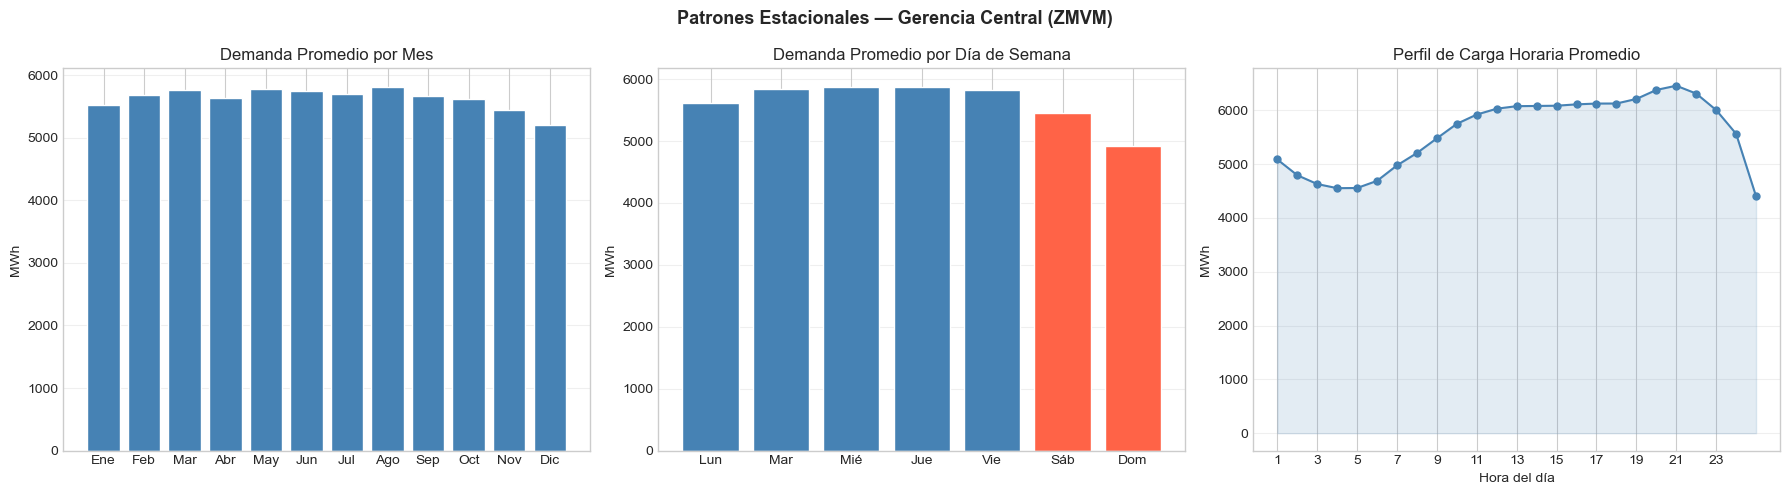

In [7]:
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
DIAS  = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Perfil mensual —
monthly = cen.groupby('mes')['demanda_balance_mwh'].mean()
axes[0].bar(range(1,13), monthly.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(MESES)
axes[0].set_title('Demanda Promedio por Mes')
axes[0].set_ylabel('MWh')

# — Perfil día de semana —
weekly = cen.groupby('dia_sem')['demanda_balance_mwh'].mean()
colors = ['steelblue']*5 + ['tomato','tomato']
axes[1].bar(range(7), weekly.values, color=colors, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(DIAS)
axes[1].set_title('Demanda Promedio por Día de Semana')

# — Perfil horario —
hourly = cen.groupby('hora')['demanda_balance_mwh'].mean()
axes[2].plot(hourly.index, hourly.values, 'o-', color='steelblue', ms=5)
axes[2].fill_between(hourly.index, hourly.values, alpha=0.15, color='steelblue')
axes[2].set_xticks(range(1,25,2))
axes[2].set_title('Perfil de Carga Horaria Promedio')
axes[2].set_xlabel('Hora del día')

for ax in axes:
    ax.set_ylabel('MWh')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Patrones Estacionales — Gerencia Central (ZMVM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_patrones_estacionales.png', dpi=150, bbox_inches='tight')
plt.show()

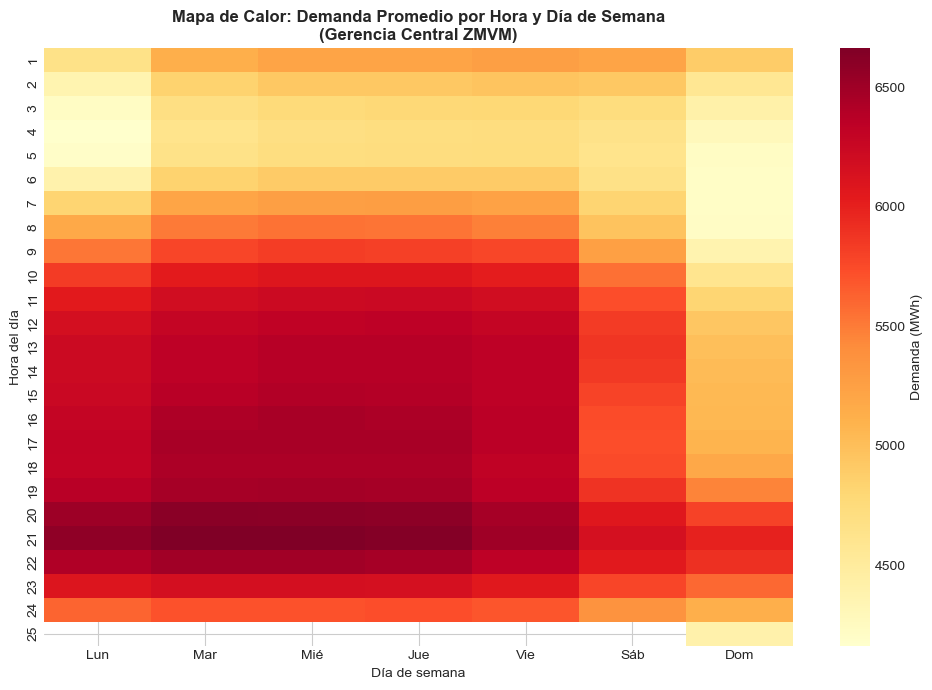

In [8]:
# Mapa de calor: Hora × Día de semana
pivot_hw = cen.pivot_table(
    values='demanda_balance_mwh',
    index='hora',
    columns='dia_sem',
    aggfunc='mean'
)
pivot_hw.columns = DIAS

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_hw, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax,
            cbar_kws={'label': 'Demanda (MWh)'})
ax.set_title('Mapa de Calor: Demanda Promedio por Hora y Día de Semana\n(Gerencia Central ZMVM)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Día de semana')
ax.set_ylabel('Hora del día')
plt.tight_layout()
plt.savefig('../reports/figures/03_heatmap_hora_dia.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Tendencia y Descomposición de Serie Temporal

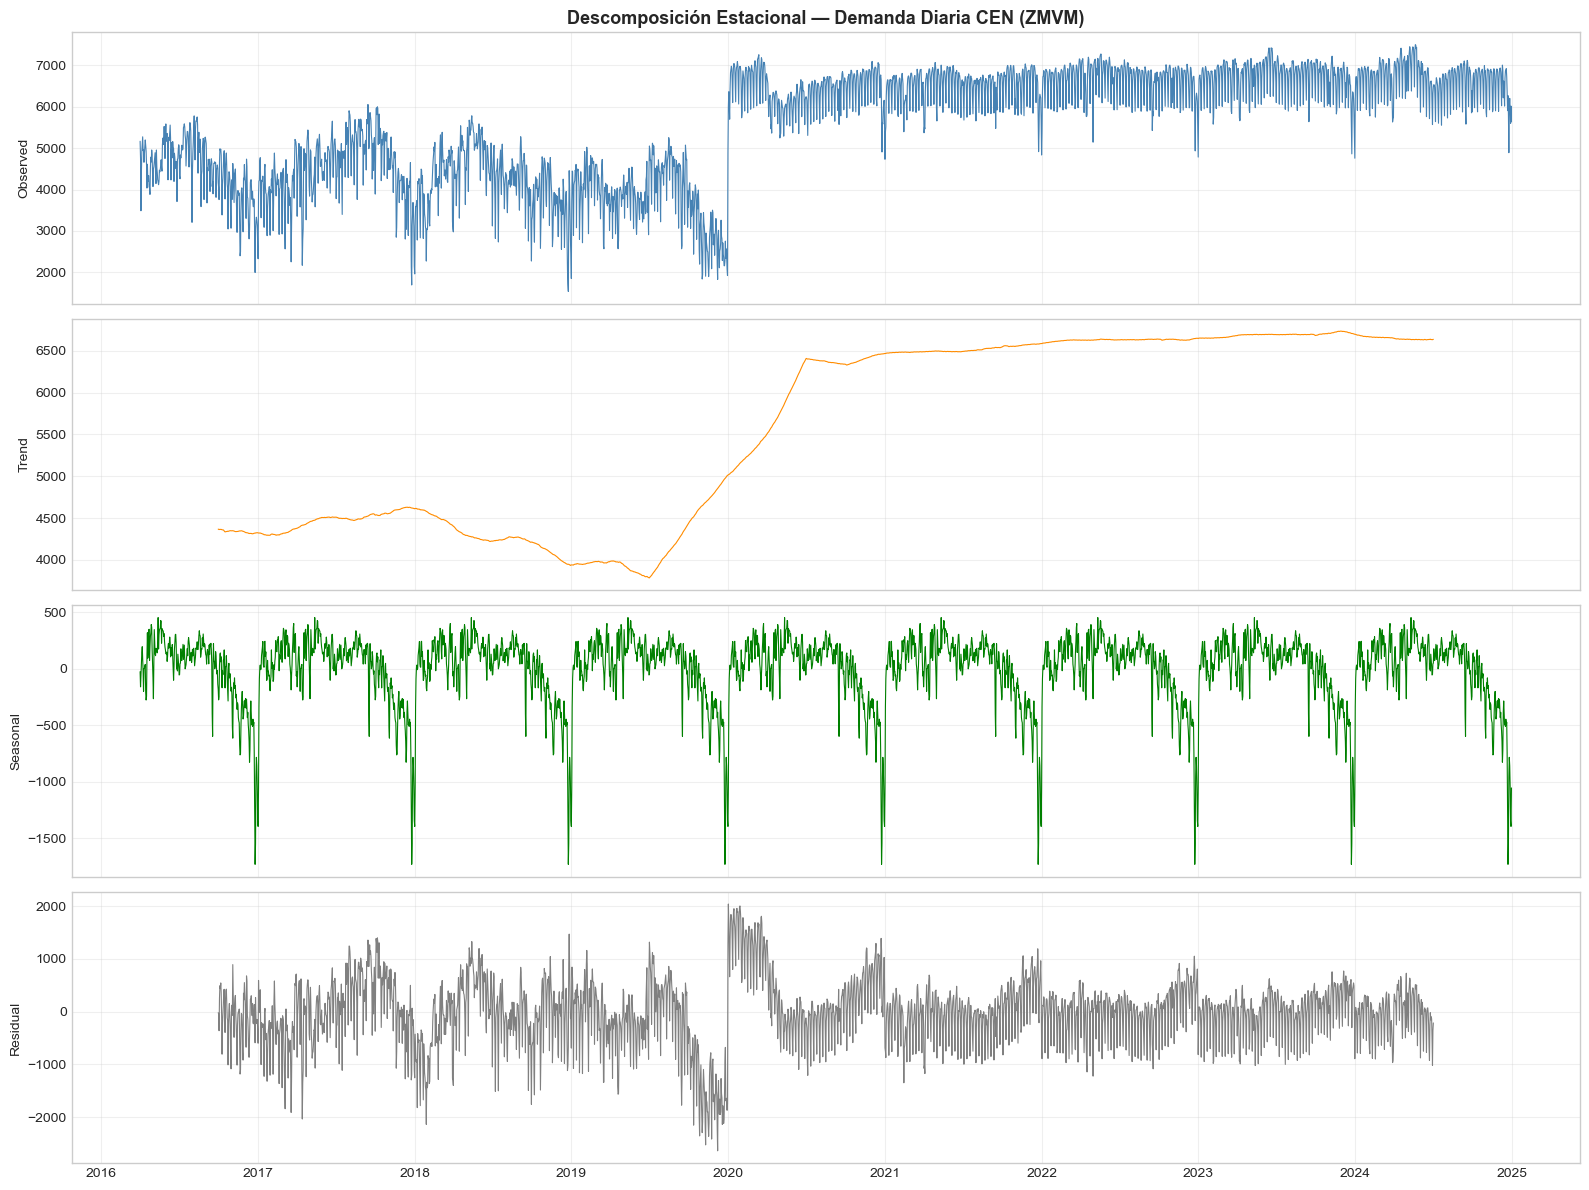

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Usar demanda diaria promedio para descomposición
daily_cen = cen.groupby('fecha')['demanda_balance_mwh'].mean().asfreq('D')
# Rellenar pequeños gaps con interpolación
daily_cen = daily_cen.interpolate(method='time', limit=7)

decomp = seasonal_decompose(daily_cen.dropna(), model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = [
    (daily_cen, 'Observed', 'steelblue'),
    (decomp.trend, 'Trend', 'darkorange'),
    (decomp.seasonal, 'Seasonal', 'green'),
    (decomp.resid, 'Residual', 'gray'),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(data, color=color, lw=0.8)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(alpha=0.3)

axes[0].set_title('Descomposición Estacional — Demanda Diaria CEN (ZMVM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_descomposicion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Análisis de Valores Extremos y Anomalías

In [10]:
# Detección por Z-score por hora (para comparar horas equivalentes)
cen['z_score'] = cen.groupby('hora')['demanda_balance_mwh'].transform(
    lambda x: (x - x.mean()) / x.std()
)

outliers = cen[cen['z_score'].abs() > 4].copy()
print(f'Outliers detectados (|z| > 4): {len(outliers)}')
print(f'Distribución por año:')
print(outliers.groupby('anio').size())
print(f'\nPrimeros 10 outliers:')
outliers[['datetime','hora','demanda_balance_mwh','z_score']].head(10)

Outliers detectados (|z| > 4): 0
Distribución por año:
Series([], dtype: int64)

Primeros 10 outliers:


,datetime,hora,demanda_balance_mwh,z_score


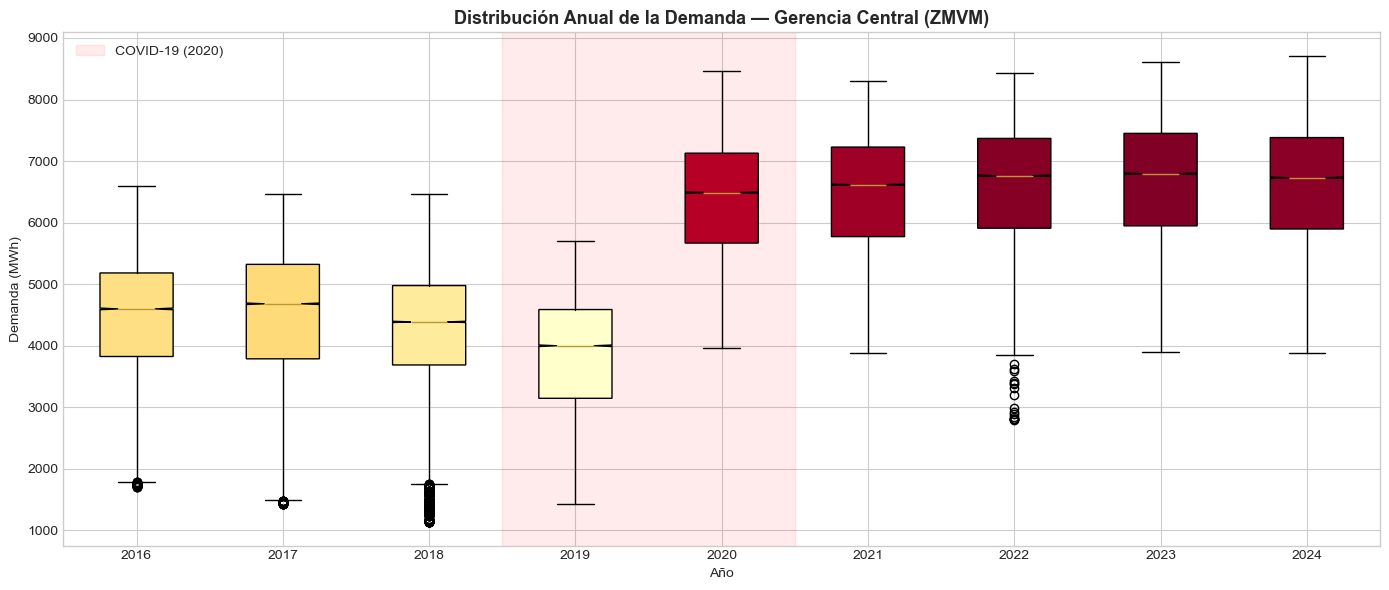

In [11]:
# Boxplot anual
fig, ax = plt.subplots(figsize=(14, 6))
anios = sorted(cen['anio'].unique())
data_by_year = [cen[cen['anio'] == y]['demanda_balance_mwh'].values for y in anios]
bp = ax.boxplot(data_by_year, labels=anios, patch_artist=True, notch=True)

# Colorear cajas por tendencia
medians = [d.median() for d in [cen[cen['anio'] == y]['demanda_balance_mwh'] for y in anios]]
norm = plt.Normalize(min(medians), max(medians))
cmap = plt.cm.YlOrRd
for patch, med in zip(bp['boxes'], medians):
    patch.set_facecolor(cmap(norm(med)))

ax.set_title('Distribución Anual de la Demanda — Gerencia Central (ZMVM)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Demanda (MWh)')
ax.axvspan(3.5, 5.5, alpha=0.08, color='red', label='COVID-19 (2020)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_boxplot_anual.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Impacto COVID-19

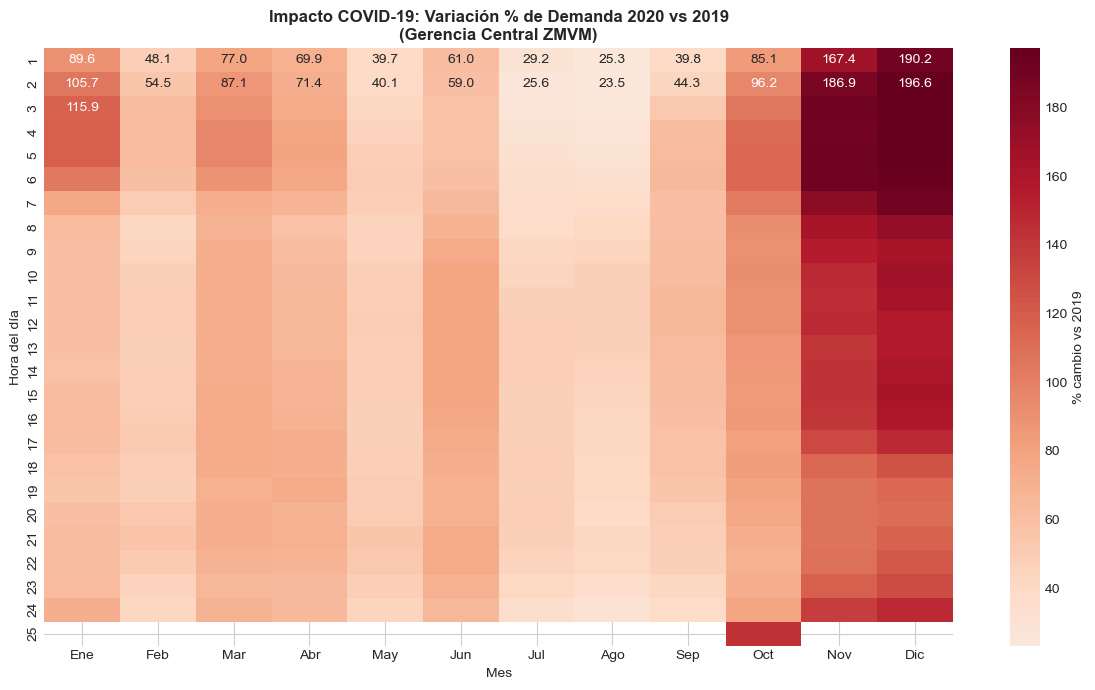

Caída máxima de demanda (2020 vs 2019): 23.3%
Mes con mayor caída: Ago


In [12]:
# Comparar 2019 vs 2020 (mismo período ene-dic)
pre_covid  = cen[cen['anio'] == 2019].groupby(['mes','hora'])['demanda_balance_mwh'].mean()
covid      = cen[cen['anio'] == 2020].groupby(['mes','hora'])['demanda_balance_mwh'].mean()

diff_pct = ((covid - pre_covid) / pre_covid * 100).reset_index()
pivot_covid = diff_pct.pivot(index='hora', columns='mes', values='demanda_balance_mwh')
pivot_covid.columns = MESES

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot_covid, cmap='RdBu_r', center=0, annot=True, fmt='.1f', ax=ax,
            cbar_kws={'label': '% cambio vs 2019'})
ax.set_title('Impacto COVID-19: Variación % de Demanda 2020 vs 2019\n(Gerencia Central ZMVM)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Hora del día')
plt.tight_layout()
plt.savefig('../reports/figures/06_impacto_covid.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Caída máxima de demanda (2020 vs 2019): {diff_pct['demanda_balance_mwh'].min():.1f}%")
print(f"Mes con mayor caída: {MESES[diff_pct.groupby('mes')['demanda_balance_mwh'].mean().idxmin()-1]}")

## 8. Comparativa entre Áreas del SIN

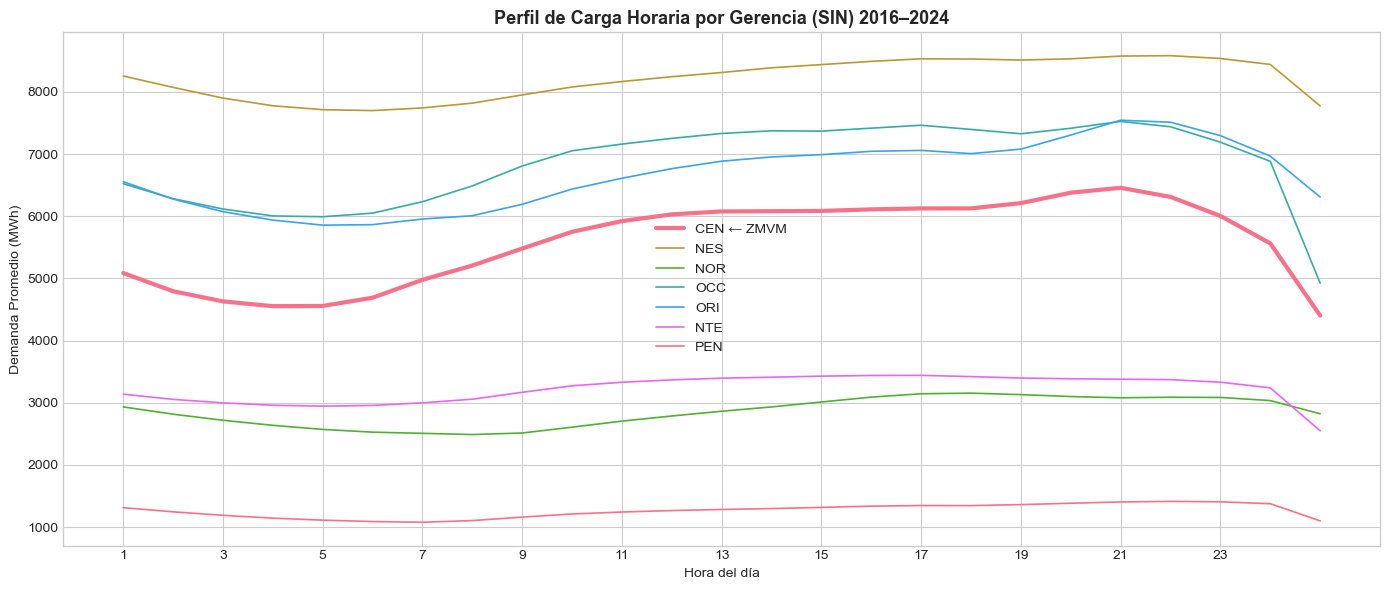

In [13]:
# Perfil horario por área
hourly_area = df.groupby(['area','hora'])['demanda_balance_mwh'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
areas_sin = ['CEN','NES','NOR','OCC','ORI','NTE','PEN']
for area in areas_sin:
    sub = hourly_area[hourly_area['area'] == area]
    lw = 3 if area == 'CEN' else 1.2
    label = f'{area} ← ZMVM' if area == 'CEN' else area
    ax.plot(sub['hora'], sub['demanda_balance_mwh'], label=label, lw=lw)

ax.set_title('Perfil de Carga Horaria por Gerencia (SIN) 2016–2024', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Demanda Promedio (MWh)')
ax.set_xticks(range(1, 25, 2))
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_perfil_horario_areas.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Resumen para Modelado

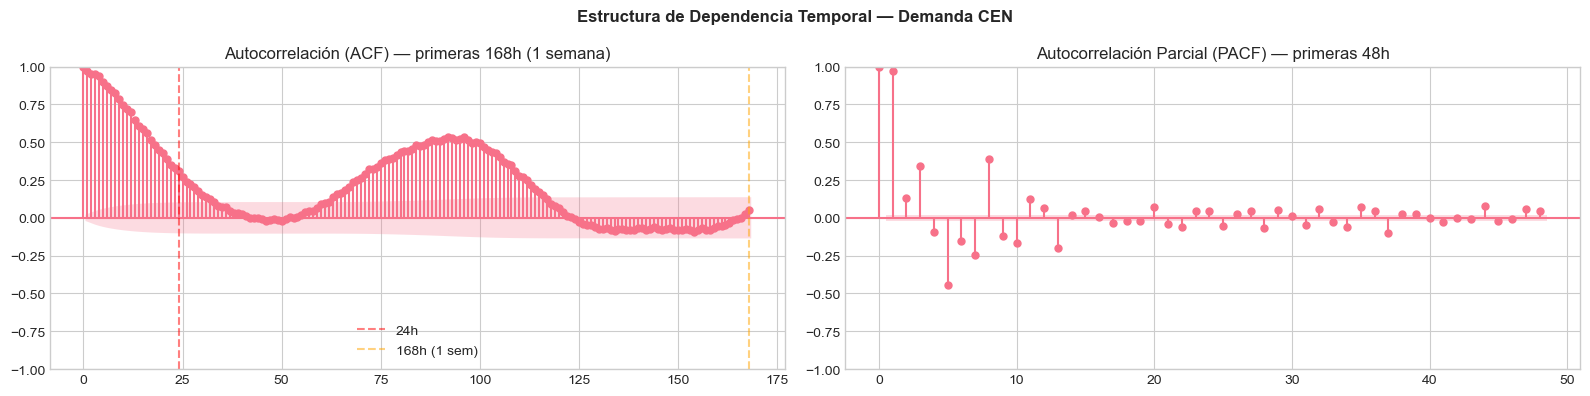

In [14]:
# Autocorrelación — ¿qué tan predictible es la demanda?
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Muestra horaria para evitar lag excesivo en plot
sample = cen['demanda_balance_mwh'].dropna().iloc[:8760]  # 1 año

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(sample, lags=168, ax=ax1, alpha=0.05)
ax1.set_title('Autocorrelación (ACF) — primeras 168h (1 semana)')
ax1.axvline(24, color='red', linestyle='--', alpha=0.5, label='24h')
ax1.axvline(168, color='orange', linestyle='--', alpha=0.5, label='168h (1 sem)')
ax1.legend()

plot_pacf(sample, lags=48, ax=ax2, alpha=0.05, method='ywm')
ax2.set_title('Autocorrelación Parcial (PACF) — primeras 48h')

fig.suptitle('Estructura de Dependencia Temporal — Demanda CEN', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_autocorrelacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print('=== RESUMEN PARA MODELADO ===')
print(f"""\n📊 DATASET DEMANDA CEN (ZMVM):
  • Observaciones: {len(cen):,} (horarias)
  • Periodo:       {cen['fecha'].min().date()} → {cen['fecha'].max().date()}
  • Años completos: {cen['anio'].nunique()}
  • Horas:         24/día

📈 VARIABLE OBJETIVO: demanda_balance_mwh
  • Media:    {cen['demanda_balance_mwh'].mean():,.0f} MWh
  • Std:      {cen['demanda_balance_mwh'].std():,.0f} MWh
  • Mínimo:   {cen['demanda_balance_mwh'].min():,.0f} MWh
  • Máximo:   {cen['demanda_balance_mwh'].max():,.0f} MWh

🎯 PATRONES IDENTIFICADOS:
  1. Estacionalidad diaria (pico ~11-14h, valle ~4-5h)
  2. Estacionalidad semanal (lun-vie > sáb-dom ~15%)
  3. Estacionalidad anual (verano > invierno)
  4. Tendencia: leve caída COVID-19 (2020 Q2: ~-{abs(diff_pct['demanda_balance_mwh'].min()):.1f}% vs 2019)
  5. Alta autocorrelación en lags 1h, 24h, 168h (7 días)

🔑 FEATURES PARA MODELADO:
  • Calendar: hora, dia_semana, mes, año, festivos MX
  • Lags:     demanda[t-1], [t-24], [t-168]
  • Rolling:  media_24h, media_168h
  • Clima:    temperatura (pendiente de integración)
""")

=== RESUMEN PARA MODELADO ===

📊 DATASET DEMANDA CEN (ZMVM):
  • Observaciones: 350,135 (horarias)
  • Periodo:       2016-04-01 → 2024-12-31
  • Años completos: 9
  • Horas:         24/día

📈 VARIABLE OBJETIVO: demanda_balance_mwh
  • Media:    5,634 MWh
  • Std:      1,472 MWh
  • Mínimo:   1,127 MWh
  • Máximo:   8,713 MWh

🎯 PATRONES IDENTIFICADOS:
  1. Estacionalidad diaria (pico ~11-14h, valle ~4-5h)
  2. Estacionalidad semanal (lun-vie > sáb-dom ~15%)
  3. Estacionalidad anual (verano > invierno)
  4. Tendencia: leve caída COVID-19 (2020 Q2: ~-23.3% vs 2019)
  5. Alta autocorrelación en lags 1h, 24h, 168h (7 días)

🔑 FEATURES PARA MODELADO:
  • Calendar: hora, dia_semana, mes, año, festivos MX
  • Lags:     demanda[t-1], [t-24], [t-168]
  • Rolling:  media_24h, media_168h
  • Clima:    temperatura (pendiente de integración)

